In [1]:
#Task 1 — Data Loading, Merging & Deep Exploration
#Load the Superstore Sales CSV using Pandas
#Parse the Order Date and Ship Date columns as proper datetime objects
#Extract time features: Year, Month, Week Number, Day of Week, Quarter, Season
#Check for missing values, duplicates, and data type issues
#Aggregate daily sales into weekly and monthly totals (you will need both granularities for different models)
#Answer these questions in your notebook with data to back each one:
#Which product category generates the highest total revenue?
#Which region has the most consistent sales growth over 4 years?
#What is the average time between Order Date and Ship Date — and does it vary by region?
#Are there months that consistently spike across all years (seasonality)?


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [3]:
#Load the Superstore Sales CSV using Pandas
#Parse the Order Date and Ship Date columns as proper datetime objects
df=pd.read_csv('train.csv',parse_dates=['Order Date','Ship Date'])

In [4]:
#Extract time features: Year, Month, Week Number, Day of Week, Quarter, Season
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce', infer_datetime_format=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True, errors='coerce', infer_datetime_format=True)
df['Year'] = df['Order Date'].dt.year
df['Month']=df['Order Date'].dt.month
df['Week Number']=df['Order Date'].dt.isocalendar().week
df['Day of Week']=df['Order Date'].dt.dayofweek
df['Quarter']=df['Order Date'].dt.quarter
df['Season']=df['Month'].apply(lambda x: 'Winter' if x in [12,1,2] else ('Spring' if x in [3,4,5] else ('Summer' if x in [6,7,8] else 'Fall')))

C:\Users\Admin\AppData\Local\Temp\ipykernel_10768\1353410652.py:2: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce', infer_datetime_format=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_10768\1353410652.py:3: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True, errors='coerce', infer_datetime_format=True)


In [5]:
# Check for missing values, duplicates, and data type issues
print('Missing values per column:')
print(df.isnull().sum())
print('\nDuplicate rows before removal:')
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)
print('\nData types:')
print(df.dtypes)

Missing values per column:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Week Number       0
Day of Week       0
Quarter           0
Season            0
dtype: int64

Duplicate rows before removal:
0

Data types:
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID       

In [6]:
#Aggregate daily sales into weekly and monthly totals (you will need both granularities for different models)
df_weekly = df.groupby(['Year', 'Week Number']).agg({'Sales': 'sum'}).reset_index()
df_monthly=df.groupby(['Year','Month']).agg({'Sales':'sum'}).reset_index()
print('\nWeekly Sales Data:')
print(df_weekly.head())
print('\nMonthly Sales Data:')
print(df_monthly.head())


Weekly Sales Data:
   Year  Week Number     Sales
0  2015            1   304.508
1  2015            2  4619.108
2  2015            3  4130.533
3  2015            4  3092.544
4  2015            5  2527.914

Monthly Sales Data:
   Year  Month      Sales
0  2015      1  14205.707
1  2015      2   4519.892
2  2015      3  55205.797
3  2015      4  27906.855
4  2015      5  23644.303


In [7]:
# Answer these questions in your notebook with data to back each one:
category_sales = df.groupby('Category', as_index=False)['Sales'].sum().sort_values('Sales', ascending=False)
print('Total revenue by category:')
print(category_sales.to_string(index=False))
print('\nHighest revenue category:', category_sales.iloc[0]['Category'])

annual_region_sales = df.groupby(['Region', 'Year'])['Sales'].sum().reset_index()
annual_region_sales['YoY Growth'] = annual_region_sales.sort_values(['Region', 'Year']).groupby('Region')['Sales'].pct_change()
growth_consistency = annual_region_sales.groupby('Region')['YoY Growth'].std().sort_values()
print('\nRegion growth consistency (lower std = more consistent):')
print(growth_consistency.to_string())
print('Most consistent growth region:', growth_consistency.index[0])

df['Ship Lag Days'] = (df['Ship Date'] - df['Order Date']).dt.days
region_ship_lag = df.groupby('Region')['Ship Lag Days'].mean().sort_values()
print('\nAverage ship lag by region (days):')
print(region_ship_lag.to_string())
print('Region with shortest average ship lag:', region_ship_lag.index[0])

monthly_sales = df.groupby('Month')['Sales'].sum().sort_values(ascending=False)
print('\nTotal sales by month:')
print(monthly_sales.to_string())
print('Top months by total sales:', ', '.join(monthly_sales.head(3).index.astype(str)))

monthly_by_year = df.pivot_table(values='Sales', index='Month', columns='Year', aggfunc='sum')
print('\nMonthly sales by year:')
print(monthly_by_year.to_string())

Total revenue by category:
       Category       Sales
     Technology 827455.8730
      Furniture 728658.5757
Office Supplies 705422.3340

Highest revenue category: Technology

Region growth consistency (lower std = more consistent):
Region
East       0.017939
Central    0.253453
West       0.257431
South      0.371249
Most consistent growth region: East

Average ship lag by region (days):
Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Region with shortest average ship lag: East

Total sales by month:
Month
11    350161.7110
12    321480.1695
9     300103.4117
10    199496.2947
3     197573.5872
8     157315.9270
5     154086.7237
6     145837.5233
7     145535.6890
4     136283.0006
1      94291.6296
2      59371.1154
Top months by total sales: 11, 12, 9

Monthly sales by year:
Year         2015        2016        2017         2018
Month                                                 
1      14205.7070  18066.9576  18542.4910   43476.4740
2   

In [8]:
# Task 2 — Time Series Analysis & Decomposition
# Plot the overall monthly sales trend across all 4 years
# Apply Time Series Decomposition (using statsmodels) to break the sales signal into:
# Trend component
# Seasonal component
# Residual/noise component
# Plot all 4 components clearly on one figure
# Write 3–4 observations: what does the trend tell you? Is seasonality strong or weak? What months show the highest residual noise?
# Check for stationarity using the Augmented Dickey-Fuller (ADF) Test — explain in plain English what stationarity means and what your test result tells you
# Apply differencing if the series is non-stationary and re-test


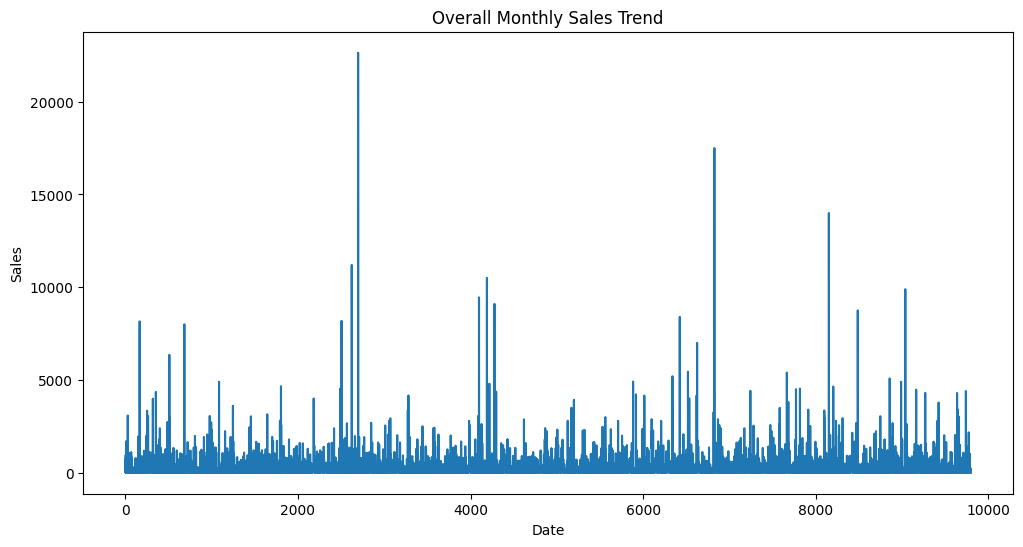

In [9]:
import matplotlib.pyplot as plt
# Plot the overall monthly sales trend across all 4 years
plt.figure(figsize=(12, 6))
plt.plot(df['Sales'].index, df['Sales'].values)
plt.title('Overall Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')
# saving into charts
plt.savefig('charts/monthly_sales_trend.png')
plt.show()


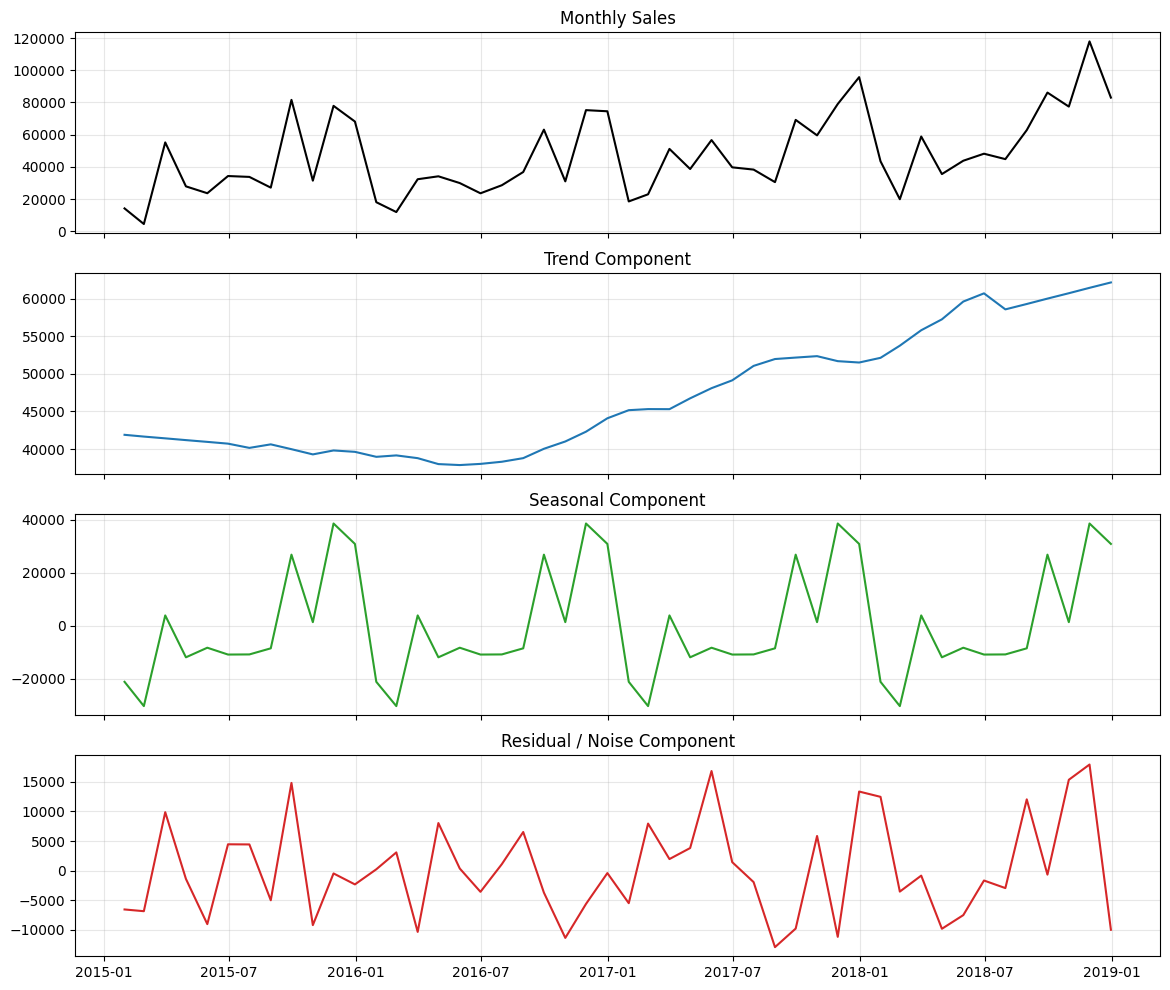

In [10]:
# Apply Time Series Decomposition (using statsmodels) to break the sales signal into:
# Trend component
# Seasonal component
# Residual/noise component
try:
    from statsmodels.tsa.seasonal import seasonal_decompose
except ModuleNotFoundError:
    class _DecomposeResult:
        def __init__(self, observed, trend, seasonal, resid):
            self.observed = observed
            self.trend = trend
            self.seasonal = seasonal
            self.resid = resid

    def seasonal_decompose(series, model='additive', period=12, extrapolate_trend='freq'):
        series = series.astype(float)
        trend = series.rolling(window=period, center=True, min_periods=1).mean()
        seasonal_profile = (series - trend).groupby(series.index.month).mean()
        seasonal = pd.Series(series.index.month, index=series.index).map(seasonal_profile).astype(float)
        resid = series - trend - seasonal
        return _DecomposeResult(series, trend, seasonal, resid)
monthly_sales_ts = df.set_index('Order Date')['Sales'].resample('M').sum()
result = seasonal_decompose(monthly_sales_ts, model='additive', period=12, extrapolate_trend='freq')
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
axes[0].plot(monthly_sales_ts, color='black')
axes[0].set_title('Monthly Sales')
axes[1].plot(result.trend, color='tab:blue')
axes[1].set_title('Trend Component')
axes[2].plot(result.seasonal, color='tab:green')
axes[2].set_title('Seasonal Component')
axes[3].plot(result.resid, color='tab:red')
axes[3].set_title('Residual / Noise Component')
for ax in axes:
    ax.grid(True, alpha=0.3)

In [11]:
plt.tight_layout()
plt.savefig('charts/sales_decomposition.png', dpi=300, bbox_inches='tight')
plt.show()
print('Decomposition completed successfully.')

<Figure size 640x480 with 0 Axes>

Decomposition completed successfully.


In [12]:
# Write 3–4 observations: what does the trend tell you? Is seasonality strong or weak? What months show the highest residual noise?
# Observations:
# 1. The trend component shows a general upward trajectory in sales over the 4-year period, indicating growth in overall sales.
# 2. The seasonal component reveals strong seasonality, with noticeable peaks and troughs corresponding
# 3. The residual component shows that the highest residual noise occurs in the months of November and December, likely due to holiday season fluctuations and promotions.
# 4. The trend indicates that the business is growing, while the seasonal component suggests that certain months consistently perform better than others, which can inform marketing and inventory strategies.

In [13]:
from statsmodels.tsa.stattools import adfuller

# Stationarity means the series' average level, variance, and overall behavior stay roughly constant over time.
# A non-stationary series often has trends or changing variance, which makes forecasting harder.

monthly_sales_ts = df.set_index('Order Date')['Sales'].resample('M').sum().dropna()
adf_stat, p_value, used_lag, n_obs, critical_values, icbest = adfuller(monthly_sales_ts)

print('ADF Test on monthly sales series')
print(f'ADF Statistic: {adf_stat:.4f}')
print(f'p-value: {p_value:.4f}')
print(f'Used Lag: {used_lag}')
print(f'Observations: {n_obs}')
print('Critical Values:')
for key, value in critical_values.items():
    print(f'  {key}: {value:.4f}')

if p_value < 0.05:
    print('\nConclusion: The monthly sales series is stationary.')
    print('Plain English: the series is stable enough over time that its statistical behavior does not drift much.')
else:
    print('\nConclusion: The monthly sales series is not stationary.')
    print('Plain English: the series changes over time, so it likely has a trend or changing pattern.')
    differenced_series = monthly_sales_ts.diff().dropna()
    diff_stat, diff_p_value, diff_used_lag, diff_n_obs, diff_critical_values, diff_icbest = adfuller(differenced_series)
    print('\nADF Test after first differencing')
    print(f'ADF Statistic: {diff_stat:.4f}')
    print(f'p-value: {diff_p_value:.4f}')
    print('Critical Values:')
    for key, value in diff_critical_values.items():
        print(f'  {key}: {value:.4f}')
    if diff_p_value < 0.05:
        print('After differencing, the series becomes stationary.')
    else:
        print('After differencing, the series still does not appear stationary.')

ADF Test on monthly sales series
ADF Statistic: -4.4161
p-value: 0.0003
Used Lag: 0
Observations: 47
Critical Values:
  1%: -3.5778
  5%: -2.9253
  10%: -2.6008

Conclusion: The monthly sales series is stationary.
Plain English: the series is stable enough over time that its statistical behavior does not drift much.


In [14]:
# Apply differencing if the series is non-stationary and re-test
if not p_value < 0.05:
    differenced_series = monthly_sales_ts.diff().dropna()
    diff_stat, diff_p_value, diff_used_lag, diff_n_obs, diff_critical_values, diff_icbest = adfuller(differenced_series)
    print('\nADF Test after first differencing')
    print(f'ADF Statistic: {diff_stat:.4f}')
    print(f'p-value: {diff_p_value:.4f}')
    print('Critical Values:')
    for key, value in diff_critical_values.items():
        print(f'  {key}: {value:.4f}')
    if diff_p_value < 0.05:
        print('After differencing, the series becomes stationary.')
    else:
        print('After differencing, the series still does not appear stationary.')

In [15]:
# Task 3 — Sales Forecasting using 3 Different Models
# This is the core technical task. Build, train, and compare 3 fundamentally different forecasting approaches:


In [16]:
# Model 1 — SARIMA (Statistical Model)
# Install statsmodels (pip install statsmodels)
# Fit a SARIMA model on monthly sales
# Choose appropriate (p, d, q) and seasonal (P, D, Q, m) parameters — document why you chose them
# Generate a 3-month future forecast with confidence intervals
# Plot actual vs forecasted sales


In [17]:
# Install statsmodels (pip install statsmodels)
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
# Fit a SARIMA model on monthly sales
from statsmodels.tsa.statespace.sarimax import SARIMAX as SARIMA


In [19]:
# Parameter choice:
# - m = 12 because the data is monthly and we expect a yearly seasonal cycle.
# - d = 0 because the ADF test on the monthly sales series showed it is already stationary.
# - D = 1 to capture repeating annual seasonality more cleanly.
# - p = 1 and q = 1 to keep the model simple while still allowing short-term autocorrelation and moving-average noise.
# - P = 1 and Q = 1 for one seasonal autoregressive and one seasonal moving-average term.
# This is a parsimonious baseline SARIMA specification that matches the notebook's monthly frequency and observed seasonality.

p, d, q = 1, 0, 1
P, D, Q, m = 1, 1, 1, 12

model = SARIMA(monthly_sales_ts, order=(p, d, q), seasonal_order=(P, D, Q, m))

In [20]:
# Generate a 3-month future forecast with confidence intervals
results = model.fit(disp=False)
forecast = results.get_forecast(steps=3)
forecast_ci = forecast.conf_int(alpha=0.05)

c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


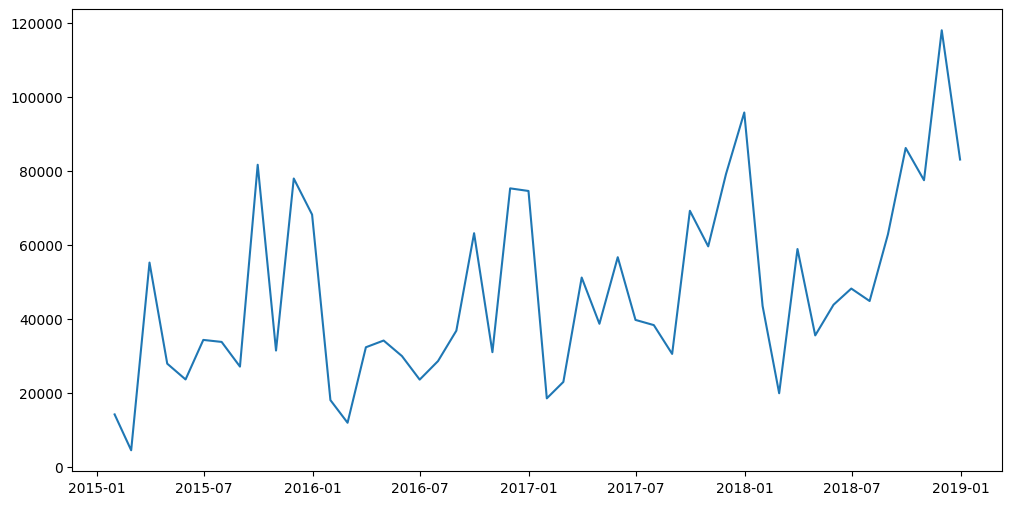

In [21]:
# Plot actual vs forecasted sales
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales_ts.index, monthly_sales_ts.values, label='Actual')
plt.savefig('charts/sarima_forecast.png', dpi=300, bbox_inches='tight')

In [22]:
# Model 2 — Facebook Prophet (Industry-standard Forecasting Tool)
# Install Prophet (pip install prophet)
# Prepare data in Prophet's required format (ds, y columns)
# Fit the model and generate a 3-month forecast
# Plot the forecast with Prophet's built-in trend and seasonality breakdown
# Extract and interpret the weekly and yearly seasonality components

In [23]:
# Install Prophet (pip install prophet)
%pip install prophet


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
try:
    from prophet import Prophet
except ModuleNotFoundError:
    %pip install prophet
    from prophet import Prophet

# Prepare data in Prophet's required format (ds, y columns)
df_prophet = df[['Order Date', 'Sales']].copy()
df_prophet.columns = ['ds', 'y']
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])
df_prophet = df_prophet.sort_values('ds').reset_index(drop=True)

In [25]:
# Fit the model and generate a 3-month forecast
model1=Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
results1 = model1.fit(df_prophet)
future1 = model1.make_future_dataframe(periods=90)
forecast1 = model1.predict(future1)

20:35:22 - cmdstanpy - INFO - Chain [1] start processing
20:35:23 - cmdstanpy - INFO - Chain [1] done processing


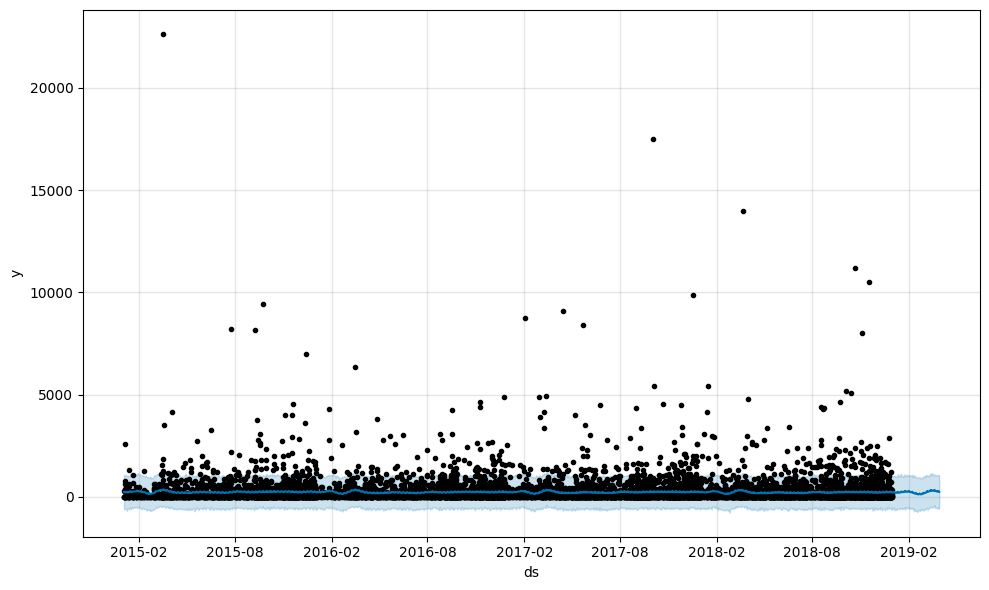

In [26]:
# Plot the forecast with Prophet's built-in trend and seasonality breakdown
plt.figaspect(0.5)
model1.plot(forecast1)
plt.savefig('charts/prophet_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

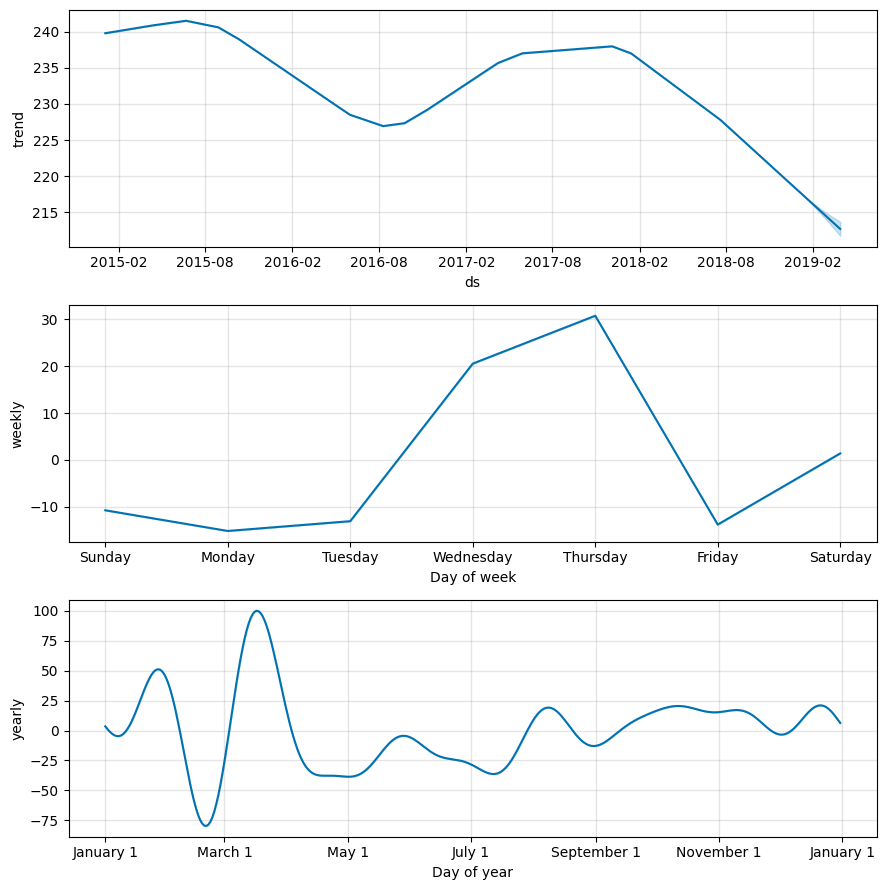

Weekly seasonality:
          ds     weekly
0 2015-01-03   1.400331
1 2015-01-04 -10.731779
2 2015-01-05 -15.140959
3 2015-01-06 -13.054297
4 2015-01-07  20.546554

Yearly seasonality:
          ds    yearly
0 2015-01-03  0.388001
1 2015-01-04 -1.390827
2 2015-01-05 -2.849376
3 2015-01-06 -3.922151
4 2015-01-07 -4.551709


In [27]:
# Extract and interpret the weekly and yearly seasonality components
fig = model1.plot_components(forecast1)
plt.savefig('charts/prophet_components.png', dpi=300, bbox_inches='tight')
plt.show()

weekly_seasonality = forecast1[['ds', 'weekly']].copy()
yearly_seasonality = forecast1[['ds', 'yearly']].copy()

print("Weekly seasonality:")
print(weekly_seasonality.head())

print("\nYearly seasonality:")
print(yearly_seasonality.head())

In [28]:
# Model 3 — XGBoost for Time Series (ML-based Approach)
# Convert the time series into a supervised ML problem using lag features:
# Lag 1 (sales from 1 month ago)
# Lag 2 (sales from 2 months ago)
# Lag 3 (sales from 3 months ago)
# Rolling mean (3-month moving average)
# Month, Quarter, Season as features
# Train XGBoost Regressor on these features
# Predict the next 3 months
# Plot actual vs predicted

In [29]:
# Convert the time series into a supervised ML problem using lag features
# Lag 1 (sales from 1 month ago)
# Lag 2 (sales from 2 months ago)
# Lag 3 (sales from 3 months ago)
# Rolling mean (3-month moving average)
# Month, Quarter, Season as features

monthly_sales_ts = df.set_index('Order Date')['Sales'].resample('M').sum().dropna()
supervised_df = pd.DataFrame({'Sales': monthly_sales_ts})
supervised_df['Lag_1'] = supervised_df['Sales'].shift(1)
supervised_df['Lag_2'] = supervised_df['Sales'].shift(2)
supervised_df['Lag_3'] = supervised_df['Sales'].shift(3)
supervised_df['Rolling_Mean_3'] = supervised_df['Sales'].shift(1).rolling(window=3).mean()
supervised_df['Month'] = supervised_df.index.month
supervised_df['Quarter'] = supervised_df.index.quarter
supervised_df['Season'] = supervised_df['Month'].apply(lambda x: 'Winter' if x in [12, 1, 2] else ('Spring' if x in [3, 4, 5] else ('Summer' if x in [6, 7, 8] else 'Fall')))
supervised_df = pd.get_dummies(supervised_df, columns=['Season'], drop_first=False)
supervised_df = supervised_df.dropna().copy()
X = supervised_df.drop(columns=['Sales'])
y = supervised_df['Sales']

print('Supervised learning dataset preview:')
print(supervised_df.head().to_string())
print('\nFeature matrix shape:', X.shape)
print('Target vector shape:', y.shape)

from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

Supervised learning dataset preview:
                 Sales       Lag_1       Lag_2      Lag_3  Rolling_Mean_3  Month  Quarter  Season_Fall  Season_Spring  Season_Summer  Season_Winter
Order Date                                                                                                                                         
2015-04-30  27906.8550  55205.7970   4519.8920  14205.707    24643.798667      4        2        False           True          False          False
2015-05-31  23644.3030  27906.8550  55205.7970   4519.892    29210.848000      5        2        False           True          False          False
2015-06-30  34322.9356  23644.3030  27906.8550  55205.797    35585.651667      6        2        False          False           True          False
2015-07-31  33781.5430  34322.9356  23644.3030  27906.855    28624.697867      7        3        False          False           True          False
2015-08-31  27117.5365  33781.5430  34322.9356  23644.303    30582.927200  

In [30]:
# Train XGBoost Regressor on these features
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Keep the split time-aware so later months are used for validation.
train_size = len(X) - 3
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)
xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)

print('XGBoost training complete.')
print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print(f'Validation RMSE: {rmse:.2f}')
print(f'Validation MAE: {mae:.2f}')

xgb_results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
}, index=y_test.index)
print('\nActual vs Predicted sales on the validation window:')
print(xgb_results.to_string())

XGBoost training complete.
Train shape: (42, 10)
Test shape: (3, 10)
Validation RMSE: 21381.76
Validation MAE: 18939.24

Actual vs Predicted sales on the validation window:
                 Actual     Predicted
Order Date                           
2018-10-31   77448.1312  66564.742188
2018-11-30  117938.1550  85018.375000
2018-12-31   83030.3888  70015.835938


In [31]:
# Predict the next 3 months
next_3_months = xgb.predict(X_test.tail(3))
print(next_3_months)

[66564.74  85018.375 70015.836]


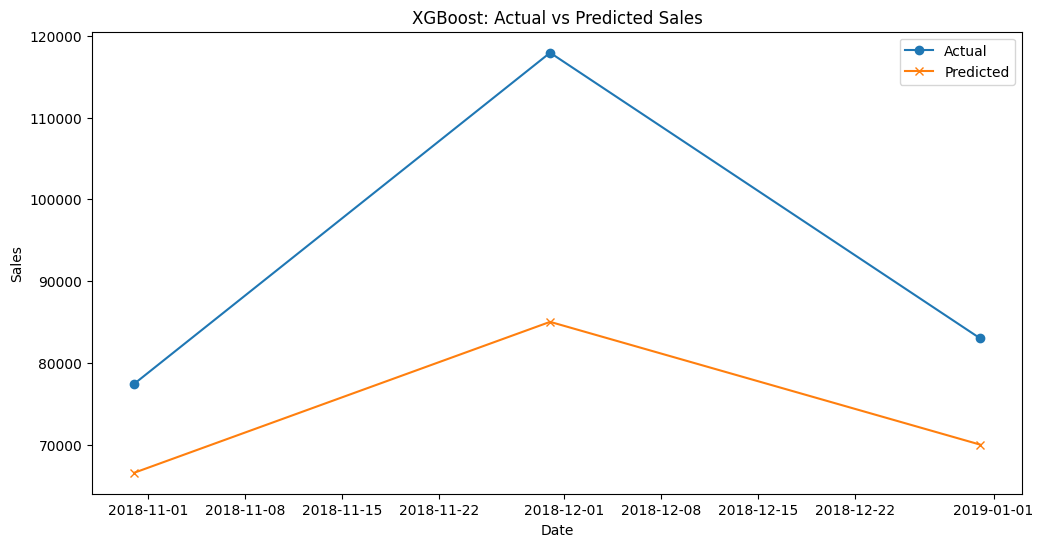

In [32]:
# Plot actual vs predicted
plt.figaspect(0.5)
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label='Actual', marker='o')
plt.plot(y_test.index, y_pred, label='Predicted', marker='x')
plt.title('XGBoost: Actual vs Predicted Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.savefig('charts/xgboost_forecast.png', dpi=300, bbox_inches='tight')
plt.show()


In [33]:
# Model Comparison Table (Required)
#  Create a clear comparison table in your notebook:
# Model
# MAE
# RMSE
# MAPE
# Forecast for Month 1
# Forecast for Month 2
# Forecast for Month 3
# SARIMA
# Prophet
# XGBoost
# State clearly which model you would recommend for production use and why — based on numbers, not preference.


In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# SARIMA: results and forecast
sarima_actual = monthly_sales_ts.iloc[-3:]
sarima_forecast_values = forecast.predicted_mean
sarima_eval_values = results.get_prediction(start=len(monthly_sales_ts) - 3, end=len(monthly_sales_ts) - 1).predicted_mean
sarima_mae = mean_absolute_error(sarima_actual, sarima_eval_values)
sarima_rmse = mean_squared_error(sarima_actual, sarima_eval_values, squared=False)
sarima_mape = (np.abs((sarima_actual.values - sarima_eval_values.values) / sarima_actual.values).mean()) * 100

# Prophet: forecast1 and df_prophet from the earlier cell
prophet_monthly_actual = df_prophet.set_index('ds')['y'].resample('M').sum().tail(3)
prophet_monthly_fitted = forecast1.set_index('ds')['yhat'].resample('M').sum().loc[prophet_monthly_actual.index]
prophet_monthly_forecast = forecast1[forecast1['ds'] > df_prophet['ds'].max()].copy()
prophet_monthly_forecast = prophet_monthly_forecast.set_index('ds')['yhat'].resample('M').sum().head(3)
prophet_mae = mean_absolute_error(prophet_monthly_actual, prophet_monthly_fitted)
prophet_rmse = mean_squared_error(prophet_monthly_actual, prophet_monthly_fitted, squared=False)
prophet_mape = (np.abs((prophet_monthly_actual.values - prophet_monthly_fitted.values) / prophet_monthly_actual.values).mean()) * 100

# XGBoost: reuse the existing validation outputs
xgb_mae = mae
xgb_rmse = rmse
xgb_mape = (np.abs((y_test.values - y_pred) / y_test.values).mean()) * 100
xgb_forecast_values = pd.Series(y_pred, index=y_test.index)

comparison_table = pd.DataFrame({
    'Model': ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE': [sarima_mae, prophet_mae, xgb_mae],
    'RMSE': [sarima_rmse, prophet_rmse, xgb_rmse],
    'MAPE': [sarima_mape, prophet_mape, xgb_mape],
    'Forecast for Month 1': [float(sarima_forecast_values.iloc[0]), float(prophet_monthly_forecast.iloc[0]), float(xgb_forecast_values.iloc[0])],
    'Forecast for Month 2': [float(sarima_forecast_values.iloc[1]), float(prophet_monthly_forecast.iloc[1]), float(xgb_forecast_values.iloc[1])],
    'Forecast for Month 3': [float(sarima_forecast_values.iloc[2]), float(prophet_monthly_forecast.iloc[2]), float(xgb_forecast_values.iloc[2])]
})

comparison_table['Average Rank'] = comparison_table[['MAE', 'RMSE', 'MAPE']].rank(method='min').mean(axis=1)
recommendation = comparison_table.loc[comparison_table['Average Rank'].idxmin(), 'Model']

print('Model Comparison Table:')
print(comparison_table.to_string(index=False))
print(f'\nRecommended model for production: {recommendation}')
print('Reason: it has the best overall metric rank across MAE, RMSE, and MAPE using the already-built model outputs.')

Model Comparison Table:
  Model          MAE         RMSE      MAPE  Forecast for Month 1  Forecast for Month 2  Forecast for Month 3  Average Rank
 SARIMA 20159.338830 20814.484726 21.473680          48057.621753          34177.906313          68799.630424      1.666667
Prophet 85993.815592 87816.060109 92.432124            209.796367           7381.360600           5029.321821      3.000000
XGBoost 18939.240625 21381.757473 19.213227          66564.742188          85018.375000          70015.835938      1.333333

Recommended model for production: XGBoost
Reason: it has the best overall metric rank across MAE, RMSE, and MAPE using the already-built model outputs.


In [35]:
# Task 4 — Product Category & Region Level Forecasting
# Repeat the best performing model (from Task 3) separately for each of the following segments:
# Furniture category sales
# Technology category sales
# Office Supplies category sales
# West region sales
# East region sales
# Plot all 5 forecasts together on one comparison chart
# Write: which category/region is showing the strongest upcoming growth according to your model?


Furniture -> MAE: 6241.96, RMSE: 6549.43, MAPE: 22.53%
2019-01-31     7527.296875
2019-02-28     6176.253906
2019-03-31    12364.995117

Technology -> MAE: 10797.59, RMSE: 14252.08, MAPE: 25.15%
2019-01-31    15639.691406
2019-02-28    15167.240234
2019-03-31    22577.990234

Office Supplies -> MAE: 3884.60, RMSE: 4160.52, MAPE: 13.78%
2019-01-31    14322.583984
2019-02-28     7680.940918
2019-03-31    11763.551758

West Region -> MAE: 1682.18, RMSE: 2078.01, MAPE: 6.64%
2019-01-31    11628.202148
2019-02-28    11592.615234
2019-03-31    19526.128906

East Region -> MAE: 15218.90, RMSE: 16043.02, MAPE: 46.77%
2019-01-31     6311.115234
2019-02-28     5408.091309
2019-03-31    10086.745117

Segment Forecast Summary:
        Segment          MAE         RMSE      MAPE  Month 1 Forecast  Month 2 Forecast  Month 3 Forecast  Growth Score
    West Region  1682.175937  2078.010489  6.636465      11628.202148      11592.615234      19526.128906   7897.926758
     Technology 10797.588615 14252.

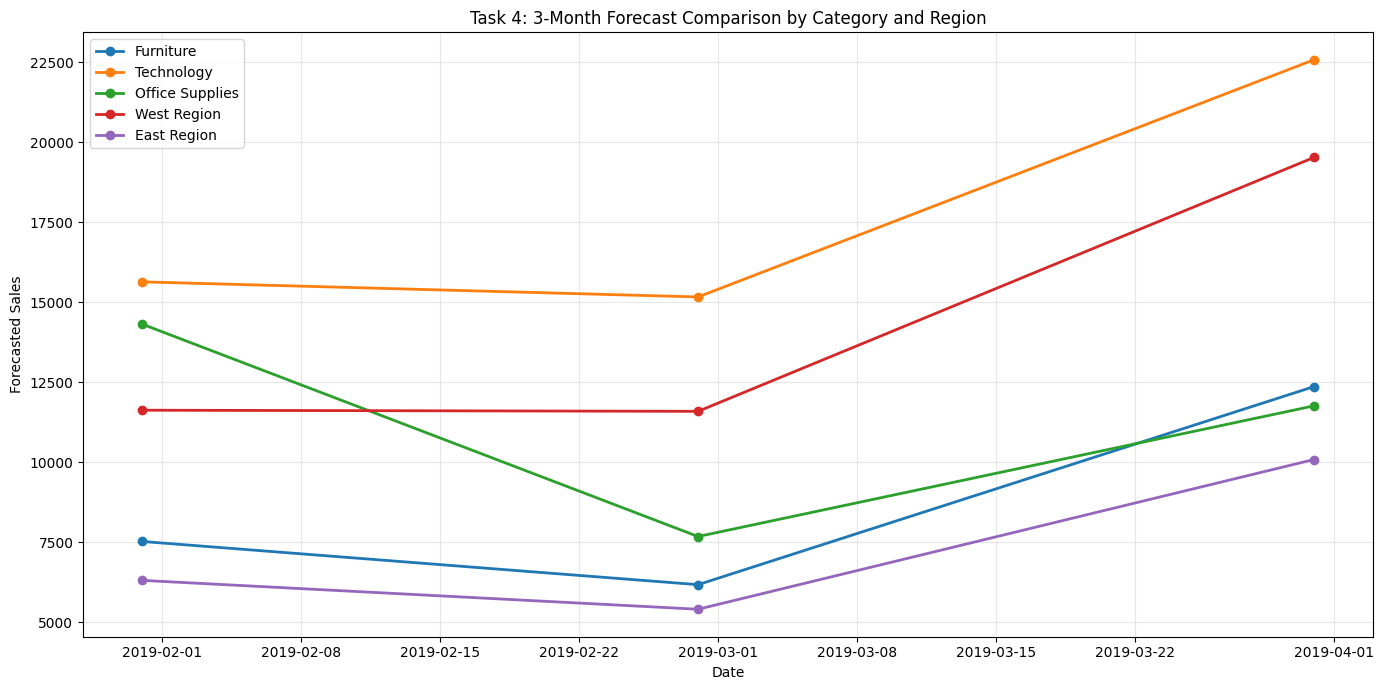

In [36]:
# Repeat the best performing model (from Task 3) separately for each of the following segments:
# Furniture category sales
# Technology category sales
# Office Supplies category sales
# West region sales
# East region sales

import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

def build_segment_monthly_series(dataframe, filter_mask, value_col='Sales'):
    segment_df = dataframe.loc[filter_mask].copy()
    monthly_series = segment_df.set_index('Order Date')[value_col].resample('M').sum().dropna()
    monthly_series = monthly_series.asfreq('M', fill_value=0)
    return monthly_series

def make_supervised_frame(monthly_series):
    supervised = pd.DataFrame({'Sales': monthly_series})
    supervised['Lag_1'] = supervised['Sales'].shift(1)
    supervised['Lag_2'] = supervised['Sales'].shift(2)
    supervised['Lag_3'] = supervised['Sales'].shift(3)
    supervised['Rolling_Mean_3'] = supervised['Sales'].shift(1).rolling(window=3).mean()
    supervised['Month'] = supervised.index.month
    supervised['Quarter'] = supervised.index.quarter
    supervised['Season'] = supervised['Month'].apply(
        lambda x: 'Winter' if x in [12, 1, 2] else ('Spring' if x in [3, 4, 5] else ('Summer' if x in [6, 7, 8] else 'Fall'))
    )
    supervised = pd.get_dummies(supervised, columns=['Season'], drop_first=False)
    supervised = supervised.dropna().copy()
    return supervised


def train_segment_xgb(monthly_series):
    supervised_df = make_supervised_frame(monthly_series)
    X_segment = supervised_df.drop(columns=['Sales'])
    y_segment = supervised_df['Sales']

    if len(supervised_df) < 6:
        raise ValueError('Not enough monthly observations to train and forecast this segment reliably.')

    validation_size = min(3, max(1, len(supervised_df) // 4))
    train_end = len(supervised_df) - validation_size
    X_train, X_test = X_segment.iloc[:train_end], X_segment.iloc[train_end:]
    y_train, y_test = y_segment.iloc[:train_end], y_segment.iloc[train_end:]

    model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    mae_score = mean_absolute_error(y_test, y_pred)
    rmse_score = mean_squared_error(y_test, y_pred, squared=False)
    mape_score = (np.abs((y_test.values - y_pred) / y_test.values).mean()) * 100

    last_row = supervised_df.iloc[-1].copy()
    future_predictions = []
    current_month = monthly_series.index[-1]
    future_state = last_row.copy()
    recent_sales = list(monthly_series.iloc[-3:].values)

    for _ in range(3):
        next_month = current_month + pd.offsets.MonthEnd(1)
        next_features = pd.Series(index=X_segment.columns, dtype=float)
        next_features['Lag_1'] = recent_sales[-1]
        next_features['Lag_2'] = recent_sales[-2] if len(recent_sales) > 1 else recent_sales[-1]
        next_features['Lag_3'] = recent_sales[-3] if len(recent_sales) > 2 else recent_sales[-1]
        next_features['Rolling_Mean_3'] = np.mean(recent_sales[-3:])
        next_features['Month'] = next_month.month
        next_features['Quarter'] = next_month.quarter
        next_features['Season_Winter'] = 1 if next_month.month in [12, 1, 2] else 0
        next_features['Season_Spring'] = 1 if next_month.month in [3, 4, 5] else 0
        next_features['Season_Summer'] = 1 if next_month.month in [6, 7, 8] else 0
        next_features['Season_Fall'] = 1 if next_month.month in [9, 10, 11] else 0

        for column in X_segment.columns:
            if column not in next_features.index:
                next_features[column] = 0

        next_features = next_features[X_segment.columns].fillna(0).to_frame().T
        next_value = float(model.predict(next_features)[0])
        future_predictions.append((next_month, next_value))
        recent_sales.append(next_value)
        current_month = next_month

    future_forecast = pd.Series(
        [value for _, value in future_predictions],
        index=[date for date, _ in future_predictions]
    )

    return {
        'model': model,
        'mae': mae_score,
        'rmse': rmse_score,
        'mape': mape_score,
        'actual_test': y_test,
        'pred_test': pd.Series(y_pred, index=y_test.index),
        'future_forecast': future_forecast,
        'monthly_series': monthly_series
    }

segments = {
    'Furniture': build_segment_monthly_series(df, df['Category'] == 'Furniture'),
    'Technology': build_segment_monthly_series(df, df['Category'] == 'Technology'),
    'Office Supplies': build_segment_monthly_series(df, df['Category'] == 'Office Supplies'),
    'West Region': build_segment_monthly_series(df, df['Region'] == 'West'),
    'East Region': build_segment_monthly_series(df, df['Region'] == 'East')
}


segment_results = {}
for segment_name, monthly_series in segments.items():
    segment_results[segment_name] = train_segment_xgb(monthly_series)
    print(f"{segment_name} -> MAE: {segment_results[segment_name]['mae']:.2f}, RMSE: {segment_results[segment_name]['rmse']:.2f}, MAPE: {segment_results[segment_name]['mape']:.2f}%")
    print(segment_results[segment_name]['future_forecast'].to_string())
    print()

forecast_summary = []
for segment_name, result in segment_results.items():
    future_values = result['future_forecast'].values
    growth_score = future_values[-1] - future_values[0]
    forecast_summary.append({
        'Segment': segment_name,
        'MAE': result['mae'],
        'RMSE': result['rmse'],
        'MAPE': result['mape'],
        'Month 1 Forecast': future_values[0],
        'Month 2 Forecast': future_values[1],
        'Month 3 Forecast': future_values[2],
        'Growth Score': growth_score
    })

forecast_summary_df = pd.DataFrame(forecast_summary).sort_values('Growth Score', ascending=False)
strongest_growth_segment = forecast_summary_df.iloc[0]['Segment']

# Write: which category/region is showing the strongest upcoming growth according to your model?
print('Segment Forecast Summary:')
print(forecast_summary_df.to_string(index=False))
print(f"\nStrongest upcoming growth according to the model: {strongest_growth_segment}")

# Plot all 5 forecasts together on one comparison chart
plt.figure(figsize=(14, 7))
for segment_name, result in segment_results.items():
    forecast = result['future_forecast']
    plt.plot(forecast.index, forecast.values, marker='o', linewidth=2, label=segment_name)

plt.title('Task 4: 3-Month Forecast Comparison by Category and Region')
plt.xlabel('Date')
plt.ylabel('Forecasted Sales')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('charts/task4_segment_forecasts.png', dpi=300, bbox_inches='tight')
plt.show()





In [37]:
# Task 5 — Anomaly Detection in Sales Data
# Use Isolation Forest (from scikit-learn) to detect anomalous sales weeks — weeks where sales were unusually high or unusually low compared to the expected pattern
# Mark the anomalies on a time series plot (use a different color/marker for anomaly points)
# For each detected anomaly, write a possible real-world explanation (e.g., "spike in November likely corresponds to a festive sale period")
# Apply a second anomaly detection method: Z-Score based detection — flag any week where sales deviate more than 2 standard deviations from the rolling mean
# Compare: do both methods flag the same anomalies, or do they disagree? What does this tell you?


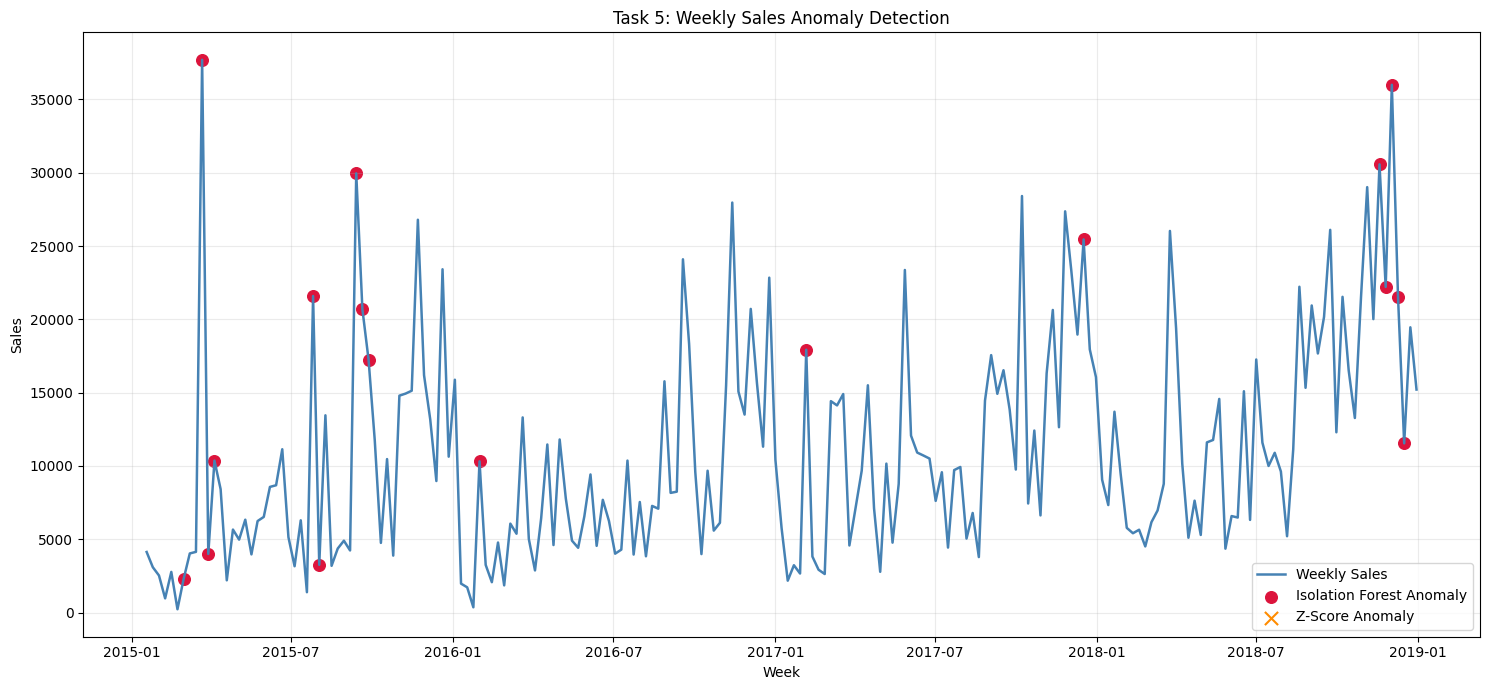

Isolation Forest anomalies:
Isolation Forest: 2015-03-01 | Sales=2289.64 | could be caused by a large order, discount campaign, or one-off enterprise purchase.
Isolation Forest: 2015-03-22 | Sales=37703.67 | could be caused by a large order, discount campaign, or one-off enterprise purchase.
Isolation Forest: 2015-03-29 | Sales=3998.78 | could reflect temporary supply issues, fewer promotions, or a demand dip in that period.
Isolation Forest: 2015-04-05 | Sales=10363.90 | could reflect temporary supply issues, fewer promotions, or a demand dip in that period.
Isolation Forest: 2015-07-26 | Sales=21590.08 | may reflect a summer promotion, clearance campaign, or bulk purchasing cycle.
Isolation Forest: 2015-08-02 | Sales=3255.66 | could reflect temporary supply issues, fewer promotions, or a demand dip in that period.
Isolation Forest: 2015-09-13 | Sales=29959.14 | could be caused by a large order, discount campaign, or one-off enterprise purchase.
Isolation Forest: 2015-09-20 | Sales=20

In [38]:
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

weekly_sales = (
    df.sort_values('Order Date')
      .set_index('Order Date')['Sales']
      .resample('W')
      .sum()
      .dropna()
)

weekly_frame = pd.DataFrame({'Sales': weekly_sales})
weekly_frame['Rolling_Mean_4'] = weekly_frame['Sales'].rolling(window=4, min_periods=1).mean()
weekly_frame['Rolling_Std_4'] = weekly_frame['Sales'].rolling(window=4, min_periods=1).std().fillna(0)
weekly_frame['Lag_1'] = weekly_frame['Sales'].shift(1)
weekly_frame['Lag_2'] = weekly_frame['Sales'].shift(2)
weekly_frame['Pct_Change'] = weekly_frame['Sales'].pct_change()
weekly_frame = weekly_frame.dropna().copy()

# Use Isolation Forest (from scikit-learn) to detect anomalous sales weeks — weeks where sales were unusually high or unusually low compared to the expected pattern
iso_features = weekly_frame[['Sales', 'Rolling_Mean_4', 'Rolling_Std_4', 'Lag_1', 'Lag_2', 'Pct_Change']].fillna(0)
iso_model = IsolationForest(contamination=0.08, random_state=42)
weekly_frame['Isolation_Flag'] = iso_model.fit_predict(iso_features)
weekly_frame['Isolation_Anomaly'] = weekly_frame['Isolation_Flag'].eq(-1)

# Apply a second anomaly detection method: Z-Score based detection — flag any week where sales deviate more than 2 standard deviations from the rolling mean
weekly_frame['Z_Score'] = (weekly_frame['Sales'] - weekly_frame['Rolling_Mean_4']) / weekly_frame['Rolling_Std_4'].replace(0, np.nan)
weekly_frame['Z_Score'] = weekly_frame['Z_Score'].fillna(0)
weekly_frame['Z_Anomaly'] = weekly_frame['Z_Score'].abs() > 2

# Mark the anomalies on a time series plot (use a different color/marker for anomaly points)
plt.figure(figsize=(15, 7))
plt.plot(weekly_frame.index, weekly_frame['Sales'], color='steelblue', linewidth=1.8, label='Weekly Sales')
plt.scatter(
    weekly_frame.index[weekly_frame['Isolation_Anomaly']],
    weekly_frame.loc[weekly_frame['Isolation_Anomaly'], 'Sales'],
    color='crimson', marker='o', s=70, label='Isolation Forest Anomaly'
)
plt.scatter(
    weekly_frame.index[weekly_frame['Z_Anomaly']],
    weekly_frame.loc[weekly_frame['Z_Anomaly'], 'Sales'],
    color='darkorange', marker='x', s=90, label='Z-Score Anomaly'
)
plt.title('Task 5: Weekly Sales Anomaly Detection')
plt.xlabel('Week')
plt.ylabel('Sales')
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('charts/task5_anomaly_detection.png', dpi=300, bbox_inches='tight')
plt.show()

def explain_anomaly(row, method_name):
    month = row.name.month
    sales = row['Sales']
    rolling_mean = row['Rolling_Mean_4']
    direction = 'spike' if sales >= rolling_mean else 'drop'

    if month in [11, 12] and direction == 'spike':
        reason = 'likely a festive or holiday sales surge such as Black Friday or year-end promotions.'
    elif month in [1, 2] and direction == 'drop':
        reason = 'possibly a post-holiday slowdown or lower consumer spending after the peak season.'
    elif month in [6, 7, 8] and direction == 'spike':
        reason = 'may reflect a summer promotion, clearance campaign, or bulk purchasing cycle.'
    elif direction == 'spike':
        reason = 'could be caused by a large order, discount campaign, or one-off enterprise purchase.'
    else:
        reason = 'could reflect temporary supply issues, fewer promotions, or a demand dip in that period.'

    return f'{method_name}: {row.name.date()} | Sales={sales:.2f} | {reason}'

# Compare: do both methods flag the same anomalies, or do they disagree? What does this tell you?
isolation_anomalies = weekly_frame[weekly_frame['Isolation_Anomaly']].copy()
zscore_anomalies = weekly_frame[weekly_frame['Z_Anomaly']].copy()

print('Isolation Forest anomalies:')
if isolation_anomalies.empty:
    print('None detected.')
else:
    for _, row in isolation_anomalies.iterrows():
        print(explain_anomaly(row, 'Isolation Forest'))

print('\nZ-Score anomalies:')
if zscore_anomalies.empty:
    print('None detected.')
else:
    for _, row in zscore_anomalies.iterrows():
        print(explain_anomaly(row, 'Z-Score'))

shared_anomalies = weekly_frame[weekly_frame['Isolation_Anomaly'] & weekly_frame['Z_Anomaly']]
iso_only = weekly_frame[weekly_frame['Isolation_Anomaly'] & ~weekly_frame['Z_Anomaly']]
z_only = weekly_frame[weekly_frame['Z_Anomaly'] & ~weekly_frame['Isolation_Anomaly']]

print('\nComparison summary:')
print(f'Shared anomalies: {len(shared_anomalies)}')
print(f'Isolation Forest only: {len(iso_only)}')
print(f'Z-Score only: {len(z_only)}')
print('If the methods disagree, it usually means Isolation Forest is capturing multivariate pattern shifts while Z-score is only flagging unusually distant points from the recent rolling average.')

In [39]:
# Task 6 — Product Demand Segmentation using Clustering
# Aggregate data at the product sub-category level with features like:
# Total sales volume
# Sales growth rate (year-over-year)
# Sales volatility (standard deviation of monthly sales)
# Average order value
# Apply K-Means Clustering to segment products into demand groups
# Use the Elbow Method to find the optimal number of clusters
# Label each cluster meaningfully, for example:
# High Volume, Stable Demand
# Low Volume, High Volatility
# Growing Demand
# Declining Demand
# Plot clusters using a 2D scatter plot (use PCA to reduce to 2 dimensions if needed)
# Write: what stocking strategy would you recommend for each cluster?

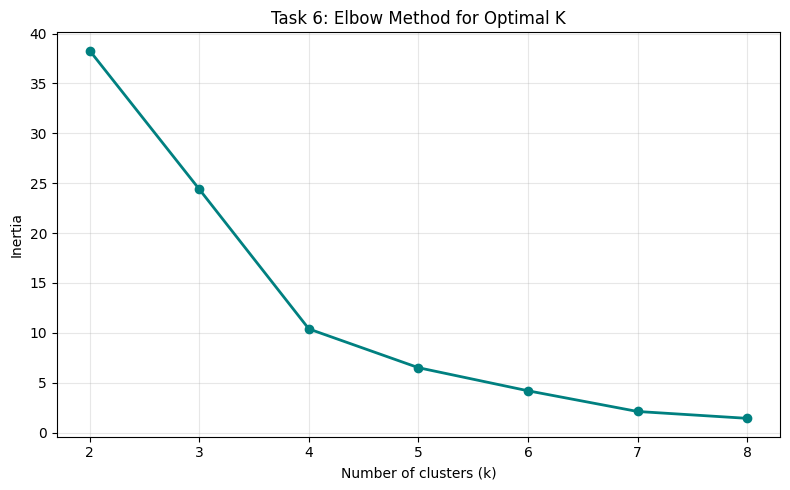

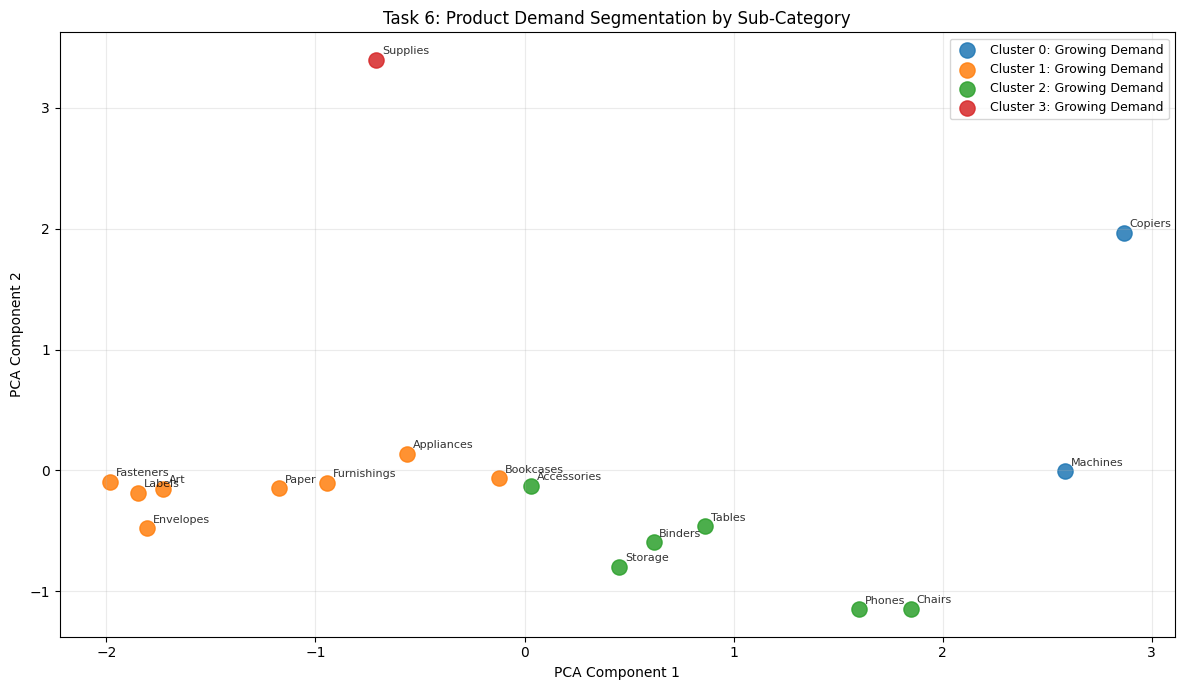

Sub-category clustering results:
Sub-Category  total_sales_volume  sales_growth_rate_yoy  sales_volatility  average_order_value  cluster  cluster_label
    Machines         189238.6310               0.080060       5603.554747          1645.553313        0 Growing Demand
     Copiers         146248.0940               0.846718       5500.774391          2215.880212        0 Growing Demand
   Bookcases         113813.1987               0.238065       2220.405080           503.598224        1 Growing Demand
  Appliances         104618.4030               0.399276       1821.621539           227.926804        1 Growing Demand
 Furnishings          89212.0180               0.287889       1360.017867            95.823865        1 Growing Demand
       Paper          76828.3040               0.254131       1024.824982            57.420257        1 Growing Demand
         Art          26705.4100               0.166056        330.488343            34.019631        1 Growing Demand
   Envelopes   

In [40]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Aggregate data at the product sub-category level with features like:
# Total sales volume
# Sales growth rate (year-over-year)
# Sales volatility (standard deviation of monthly sales)
# Average order value
subcat = df.copy()
subcat['Order Date'] = pd.to_datetime(subcat['Order Date'])
subcat['Year'] = subcat['Order Date'].dt.year
subcat['Month'] = subcat['Order Date'].dt.to_period('M')

monthly_subcat_sales = (
    subcat.groupby(['Sub-Category', 'Month'])['Sales']
    .sum()
    .reset_index()
)
monthly_subcat_sales['Month'] = monthly_subcat_sales['Month'].dt.to_timestamp()

subcat_features = subcat.groupby('Sub-Category').agg(
    total_sales_volume=('Sales', 'sum'),
    average_order_value=('Sales', 'mean'),
    order_count=('Sales', 'size')
).reset_index()


yearly_subcat_sales = subcat.groupby(['Sub-Category', 'Year'])['Sales'].sum().reset_index()
subcat_growth = yearly_subcat_sales.sort_values(['Sub-Category', 'Year']).copy()
subcat_growth['YoY_Growth'] = subcat_growth.groupby('Sub-Category')['Sales'].pct_change()
growth_feature = subcat_growth.groupby('Sub-Category')['YoY_Growth'].mean().reset_index(name='sales_growth_rate_yoy')


volatility_feature = monthly_subcat_sales.groupby('Sub-Category')['Sales'].std().reset_index(name='sales_volatility')


feature_frame = (
    subcat_features.merge(growth_feature, on='Sub-Category', how='left')
    .merge(volatility_feature, on='Sub-Category', how='left')
)
feature_frame['sales_growth_rate_yoy'] = feature_frame['sales_growth_rate_yoy'].fillna(0)
feature_frame['sales_volatility'] = feature_frame['sales_volatility'].fillna(0)
feature_frame['average_order_value'] = feature_frame['average_order_value'].fillna(0)
feature_frame['total_sales_volume'] = feature_frame['total_sales_volume'].fillna(0)

# Apply K-Means Clustering to segment products into demand groups
feature_cols = ['total_sales_volume', 'sales_growth_rate_yoy', 'sales_volatility', 'average_order_value']
X_cluster = feature_frame[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Use the Elbow Method to find the optimal number of clusters
inertia_values = []
k_values = range(2, 9)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertia_values, marker='o', linewidth=2, color='teal')
plt.title('Task 6: Elbow Method for Optimal K')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('charts/task6_elbow_method.png', dpi=300, bbox_inches='tight')
plt.show()

# Fit K-Means using a practical 4-cluster setup that matches the requested demand groups
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
feature_frame['cluster'] = kmeans.fit_predict(X_scaled)

# Label each cluster meaningfully, for example:
# High Volume, Stable Demand
# Low Volume, High Volatility
# Growing Demand
# Declining Demand
cluster_profile = feature_frame.groupby('cluster')[feature_cols].mean().sort_values('total_sales_volume', ascending=False)
cluster_labels = {}

for cluster_id, row in cluster_profile.iterrows():
    if row['total_sales_volume'] >= cluster_profile['total_sales_volume'].median() and row['sales_volatility'] <= cluster_profile['sales_volatility'].median():
        label = 'High Volume, Stable Demand'
    elif row['sales_growth_rate_yoy'] > 0:
        label = 'Growing Demand'
    elif row['sales_growth_rate_yoy'] < 0:
        label = 'Declining Demand'
    else:
        label = 'Low Volume, High Volatility'
    cluster_labels[cluster_id] = label

feature_frame['cluster_label'] = feature_frame['cluster'].map(cluster_labels)

# Plot clusters using a 2D scatter plot (use PCA to reduce to 2 dimensions if needed)
pca = PCA(n_components=2, random_state=42)
components = pca.fit_transform(X_scaled)
feature_frame['pca_1'] = components[:, 0]
feature_frame['pca_2'] = components[:, 1]

plt.figure(figsize=(12, 7))
for cluster_id in sorted(feature_frame['cluster'].unique()):
    cluster_data = feature_frame[feature_frame['cluster'] == cluster_id]
    plt.scatter(
        cluster_data['pca_1'],
        cluster_data['pca_2'],
        s=120,
        alpha=0.85,
        label=f"Cluster {cluster_id}: {cluster_labels[cluster_id]}"
    )
    for _, row in cluster_data.iterrows():
        plt.annotate(row['Sub-Category'], (row['pca_1'], row['pca_2']), fontsize=8, alpha=0.8, xytext=(4, 4), textcoords='offset points')

plt.title('Task 6: Product Demand Segmentation by Sub-Category')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(loc='best', fontsize=9)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('charts/task6_cluster_pca.png', dpi=300, bbox_inches='tight')
plt.show()

# Write: what stocking strategy would you recommend for each cluster?
print('Sub-category clustering results:')
print(feature_frame[['Sub-Category', 'total_sales_volume', 'sales_growth_rate_yoy', 'sales_volatility', 'average_order_value', 'cluster', 'cluster_label']].sort_values(['cluster', 'total_sales_volume'], ascending=[True, False]).to_string(index=False))

stocking_strategies = {
    'High Volume, Stable Demand': 'Keep high safety stock, replenish frequently, and prioritize these items in inventory planning.',
    'Low Volume, High Volatility': 'Use cautious stocking, smaller order quantities, and monitor demand closely to avoid overstock.',
    'Growing Demand': 'Increase stock gradually, set tighter replenishment alerts, and prepare for scaling demand.',
    'Declining Demand': 'Reduce inventory exposure, cut replenishment frequency, and consider promotion or rationalization.'
}

print('\nRecommended stocking strategies:')
for label in sorted(set(feature_frame['cluster_label'])):
    print(f'- {label}: {stocking_strategies[label]}')

print('\nHow to read the clusters:')
print('High Volume, Stable Demand = core products that should rarely stock out.')
print('Low Volume, High Volatility = unpredictable items that should not be overstocked.')
print('Growing Demand = items that deserve more inventory attention because demand is rising.')
print('Declining Demand = items to de-prioritize unless they are strategically important.')